In [2]:
%load_ext autoreload
%autoreload 2

In [22]:
from data import build_all
from distances import compute_euclidean_distances, compute_mahalanobis_distances

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

In [4]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

In [5]:
pitch_type_r.head()

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Wainwright, Adam",2021,CH,82.729744,-1.152821,0.643179,195
1,"Wainwright, Adam",2022,CH,82.182540,-1.192593,0.668889,189
2,"Wainwright, Adam",2023,CH,81.431461,-1.168652,0.729663,89
3,"Greinke, Zack",2021,CH,86.350791,-1.065747,0.371793,569
4,"Greinke, Zack",2022,CH,86.468984,-1.067433,0.317032,374


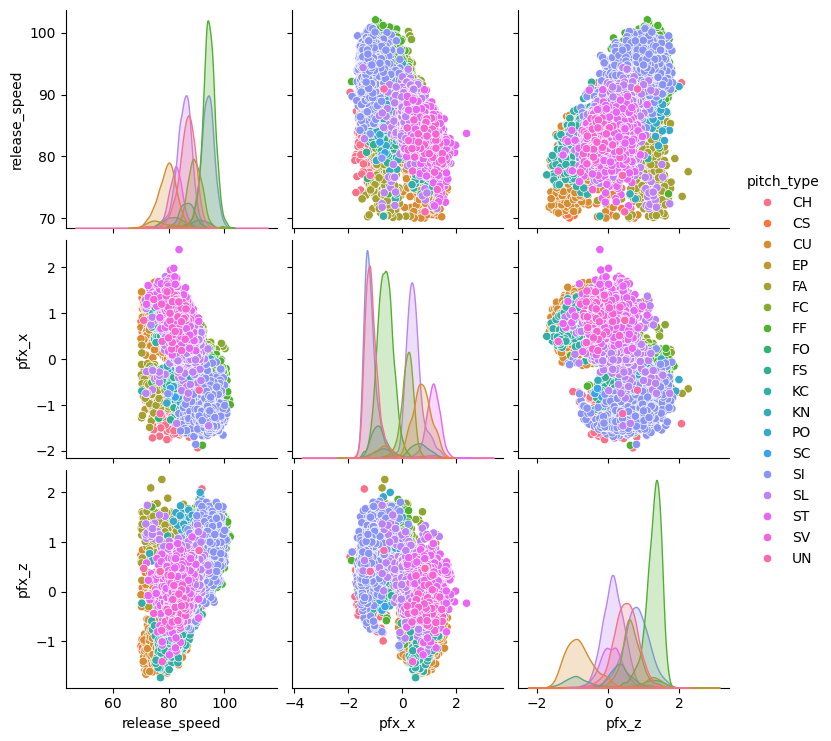

In [10]:
sns.pairplot(
    pitch_type_r,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
)

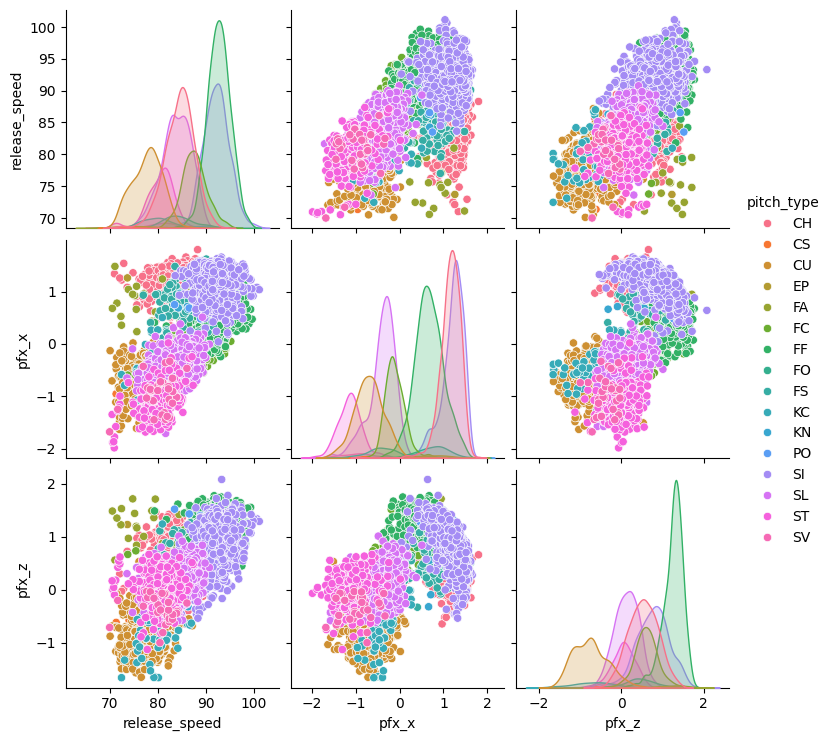

In [12]:
sns.pairplot(
    pitch_type_l,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
)

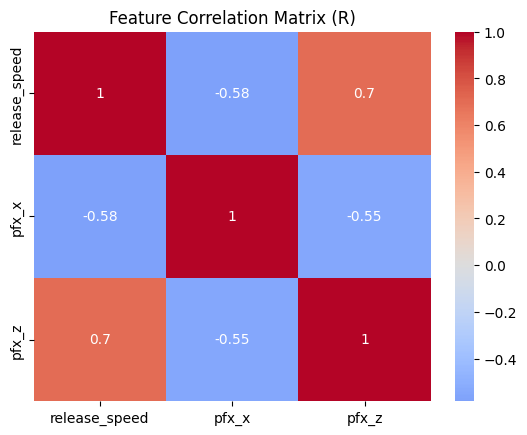

In [19]:
corr_r = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_r, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

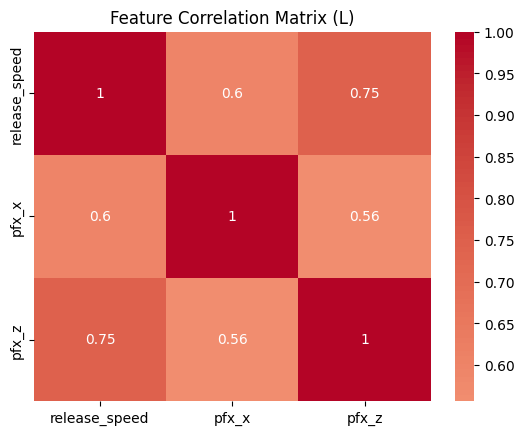

In [20]:
corr_l = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_l, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

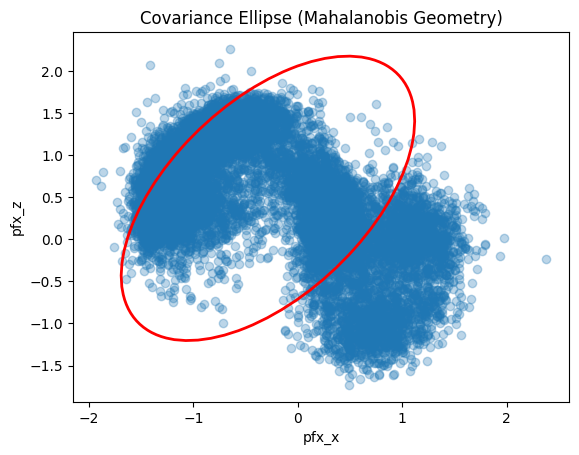

In [23]:
X = pitch_type_r[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

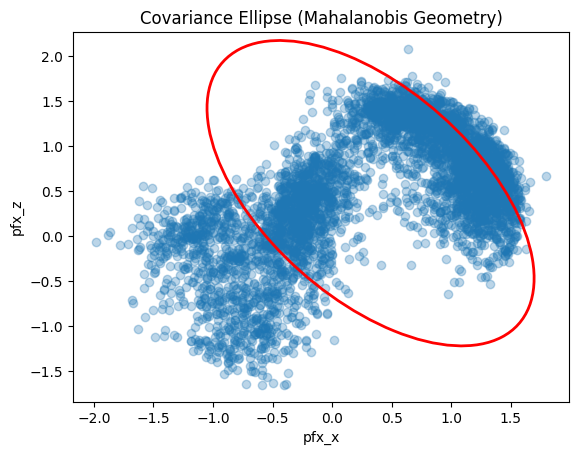

In [24]:
X = pitch_type_l[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()